# E-Commerce Sales Analytics System

## Exploratory Data Analysis (EDA)

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Set figure size
plt.rcParams["figure.figsize"] = (10, 6)

## Load Datasets

In [45]:
categories_df = pd.read_csv("../data/categories.csv")
products_df = pd.read_csv("../data/products.csv")
customers_df = pd.read_csv("../data/customers.csv")
orders_df = pd.read_csv("../data/orders.csv")
order_items_df = pd.read_csv("../data/order_items.csv")
payments_df = pd.read_csv("../data/payments.csv")

## Dataset Overview

In [46]:
datasets = {
    "Categories": categories_df,
    "Products": products_df,
    "Customers": customers_df,
    "Orders": orders_df,
    "Order Items": order_items_df,
    "Payments": payments_df
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"{name} Dataset")
    print(f"{'='*50}")

    print("\nShape:")
    print(df.shape)

    print("\nFirst 5 Rows:")
    display(df.head())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())


Categories Dataset

Shape:
(10, 2)

First 5 Rows:


,category_id,category_name
0,1,Electronics
1,2,Clothing
2,3,Books
3,4,Home Appliances
4,5,Beauty



Missing Values:
category_id      0
category_name    0
dtype: int64

Duplicate Rows:
0

Products Dataset

Shape:
(50, 9)

First 5 Rows:


,product_id,product_name,category_id,brand,rating,price,stock_quantity,discount_percentage,cost_price
0,1,iPhone 16,1,Apple,3.9,93810,124,0,56989.88
1,2,Samsung Galaxy S25,1,Samsung,4.6,28289,289,30,17843.25
2,3,Dell Inspiron Laptop,1,Dell,3.5,21395,121,20,15545.11
3,4,Sony Headphones,1,Sony,4.3,40495,376,20,31610.62
4,5,Apple Watch,1,Apple,3.8,95181,311,30,72669.02



Missing Values:
product_id             0
product_name           0
category_id            0
brand                  0
rating                 0
price                  0
stock_quantity         0
discount_percentage    0
cost_price             0
dtype: int64

Duplicate Rows:
0

Customers Dataset

Shape:
(100, 8)

First 5 Rows:


...


Missing Values:
order_id         0
customer_id      0
order_date       0
shipping_city    0
order_status     0
total_amount     0
dtype: int64

Duplicate Rows:
0

Order Items Dataset

Shape:
(3056, 7)

First 5 Rows:


,order_item_id,order_id,product_id,quantity,unit_price,discount_percentage,final_price
0,1,1,14,3,366,10,988.2
1,2,1,40,3,1892,20,4540.8
2,3,1,31,2,2744,30,3841.6
3,4,1,46,3,3534,5,10071.9
4,5,2,30,2,4815,20,7704.0



Missing Values:
order_item_id          0
order_id               0
product_id             0
quantity               0
unit_price             0
discount_percentage    0
final_price            0
dtype: int64

Duplicate Rows:
0

Payments Dataset

Shape:
(1000, 6)

First 5 Rows:


,payment_id,order_id,payment_method,payment_status,payment_date,transaction_amount
0,1,1,Debit Card,Success,2025-09-17,19442.5
1,2,2,Net Banking,Success,2025-07-16,8873.6
2,3,3,Net Banking,Success,2025-02-28,39604.6
3,4,4,UPI,Success,2025-03-07,10419.6
4,5,5,UPI,Success,2025-10-28,25897.2



Missing Values:
payment_id            0
order_id              0
payment_method        0
payment_status        0
payment_date          0
transaction_amount    0
dtype: int64

Duplicate Rows:
0


## Products Dataset Analysis

In [47]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           50 non-null     int64  
 1   product_name         50 non-null     str    
 2   category_id          50 non-null     int64  
 3   brand                50 non-null     str    
 4   rating               50 non-null     float64
 5   price                50 non-null     int64  
 6   stock_quantity       50 non-null     int64  
 7   discount_percentage  50 non-null     int64  
 8   cost_price           50 non-null     float64
dtypes: float64(2), int64(5), str(2)
memory usage: 4.4 KB


In [48]:
products_df.describe()

,product_id,category_id,rating,price,stock_quantity,discount_percentage,cost_price
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,5.500000,4.250000,13529.040000,293.140000,12.200000,9908.046400
std,14.57738,2.901442,0.455017,23181.335097,145.377203,9.854037,16868.318811
min,1.00000,1.000000,3.500000,303.000000,11.000000,0.000000,207.070000
25%,13.25000,3.000000,3.900000,1189.250000,187.250000,5.000000,819.522500
50%,25.50000,5.500000,4.300000,2805.500000,313.000000,10.000000,2154.380000
75%,37.75000,8.000000,4.600000,9512.750000,406.000000,20.000000,7670.302500
max,50.00000,10.000000,5.000000,95181.000000,485.000000,30.000000,72669.020000


In [49]:
products_df.describe(include="object")

C:\Users\Hp\AppData\Local\Temp\ipykernel_15372\3047814107.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  products_df.describe(include="object")


,product_name,brand
count,50,50
unique,50,40
top,iPhone 16,Nike
freq,1,3


## Customers Dataset Analysis

In [50]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       100 non-null    int64
 1   customer_name     100 non-null    str  
 2   email             100 non-null    str  
 3   city              100 non-null    str  
 4   signup_date       100 non-null    str  
 5   gender            100 non-null    str  
 6   age               100 non-null    int64
 7   customer_segment  100 non-null    str  
dtypes: int64(2), str(6)
memory usage: 12.7 KB


In [51]:
customers_df.describe()

,customer_id,age
count,100.000000,100.000000
mean,50.500000,40.100000
std,29.011492,11.618081
min,1.000000,18.000000
25%,25.750000,33.000000
50%,50.500000,41.500000
75%,75.250000,48.000000
max,100.000000,60.000000


In [52]:
customers_df.describe(include="object")

C:\Users\Hp\AppData\Local\Temp\ipykernel_15372\2646819815.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  customers_df.describe(include="object")


,customer_name,email,city,signup_date,gender,customer_segment
count,100,100,100,100,100,100
unique,100,100,10,93,2,4
top,Yachana Khalsa,yachana.khalsa19@gmail.com,Jaipur,2025-10-20,Male,Gold
freq,1,1,14,2,50,31


## Orders Dataset Analysis

In [53]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       1000 non-null   int64  
 1   customer_id    1000 non-null   int64  
 2   order_date     1000 non-null   str    
 3   shipping_city  1000 non-null   str    
 4   order_status   1000 non-null   str    
 5   total_amount   1000 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 72.0 KB


In [54]:
orders_df.describe()

,order_id,customer_id,total_amount
count,1000.000000,1000.000000,1000.000000
mean,500.500000,53.096000,72200.088200
std,288.819436,28.882468,83326.458183
min,1.000000,1.000000,243.200000
25%,250.750000,29.000000,11026.337500
50%,500.500000,53.000000,40550.850000
75%,750.250000,79.000000,107485.000000
max,1000.000000,100.000000,724357.100000


## Payments Dataset Analysis

In [55]:
payments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   payment_id          1000 non-null   int64  
 1   order_id            1000 non-null   int64  
 2   payment_method      1000 non-null   str    
 3   payment_status      1000 non-null   str    
 4   payment_date        1000 non-null   str    
 5   transaction_amount  1000 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 73.4 KB


In [56]:
payments_df.describe()

,payment_id,order_id,transaction_amount
count,1000.000000,1000.000000,1000.000000
mean,500.500000,500.500000,72200.088200
std,288.819436,288.819436,83326.458183
min,1.000000,1.000000,243.200000
25%,250.750000,250.750000,11026.337500
50%,500.500000,500.500000,40550.850000
75%,750.250000,750.250000,107485.000000
max,1000.000000,1000.000000,724357.100000


In [57]:
payments_df.describe(include="object")

C:\Users\Hp\AppData\Local\Temp\ipykernel_15372\3262150005.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  payments_df.describe(include="object")


,payment_method,payment_status,payment_date
count,1000,1000,1000
unique,5,3,344
top,Net Banking,Success,2025-10-17
freq,215,891,10


## Products Analysis

In [58]:
products_df["category_id"].value_counts().sort_index()

category_id
1     5
2     5
3     5
4     5
5     5
6     5
7     5
8     5
9     5
10    5
Name: count, dtype: int64

In [59]:
products_df["brand"].value_counts()

brand
Nike             3
Apple            2
Samsung          2
Adidas           2
Puma             2
Penguin          2
HarperCollins    2
Nivea            2
Fortune          2
Dell             1
Sony             1
Levi's           1
Zara             1
Bloomsbury       1
LG               1
Whirlpool        1
Panasonic        1
Philips          1
Maybelline       1
L'Oreal          1
Dove             1
SG               1
Yonex            1
Hot Wheels       1
Barbie           1
Lego             1
Funskool         1
Disney           1
Aashirvaad       1
Amul             1
Tata             1
Godrej           1
Nilkamal         1
IKEA             1
Durian           1
Urban Ladder     1
Wildcraft        1
Titan            1
Ray-Ban          1
Fastrack         1
Name: count, dtype: int64

In [60]:
products_df["rating"].describe()

count    50.000000
mean      4.250000
std       0.455017
min       3.500000
25%       3.900000
50%       4.300000
75%       4.600000
max       5.000000
Name: rating, dtype: float64

In [61]:
products_df["price"].describe()

count       50.000000
mean     13529.040000
std      23181.335097
min        303.000000
25%       1189.250000
50%       2805.500000
75%       9512.750000
max      95181.000000
Name: price, dtype: float64

## Customers Analysis

In [62]:
customers_df["gender"].value_counts()

gender
Male      50
Female    50
Name: count, dtype: int64

In [63]:
customers_df["customer_segment"].value_counts()

customer_segment
Gold       31
Silver     28
Regular    21
Premium    20
Name: count, dtype: int64

In [64]:
customers_df["age"].describe()

count    100.000000
mean      40.100000
std       11.618081
min       18.000000
25%       33.000000
50%       41.500000
75%       48.000000
max       60.000000
Name: age, dtype: float64

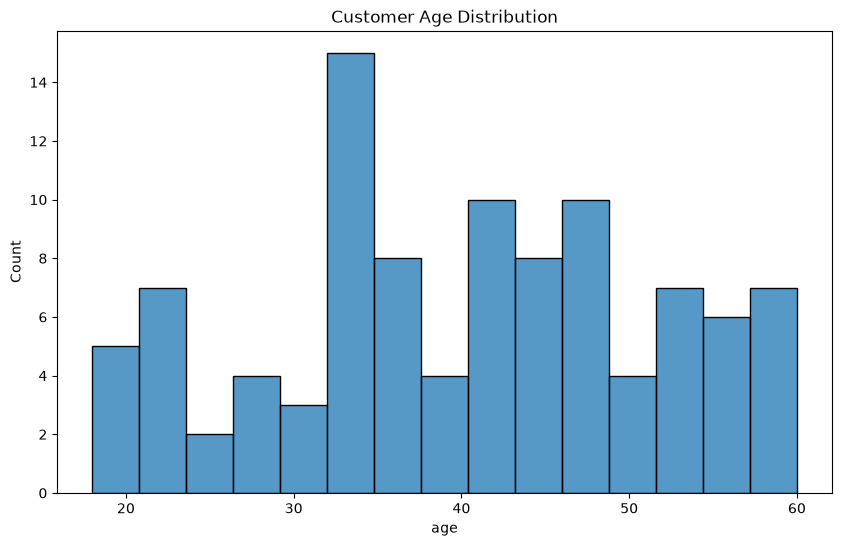

In [65]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=customers_df,
    x="age",
    bins=15
)

plt.title("Customer Age Distribution")

plt.show()

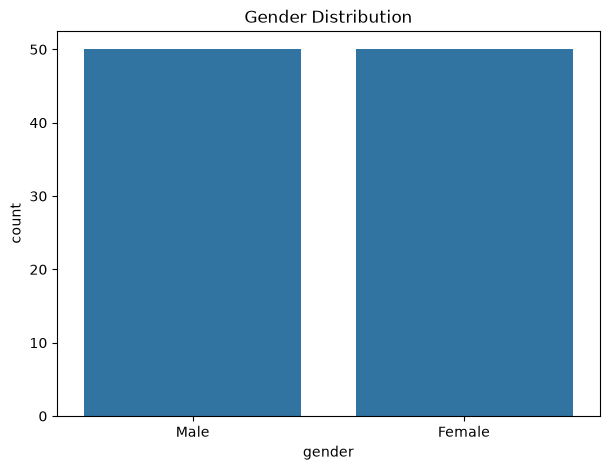

In [66]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=customers_df,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

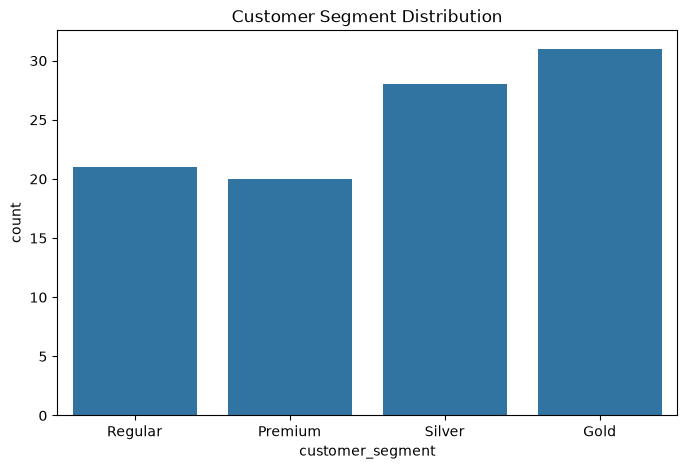

In [67]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers_df,
    x="customer_segment"
)

plt.title("Customer Segment Distribution")

plt.show()

In [68]:
customers_df["city"].value_counts().head(10)

city
Jaipur       14
Mumbai       12
Delhi        12
Bhopal       11
Hyderabad    11
Indore       11
Chennai       9
Ahmedabad     7
Bangalore     7
Pune          6
Name: count, dtype: int64

## Orders Analysis

In [69]:
orders_df["order_status"].value_counts()

order_status
Delivered     802
Shipped        89
Processing     82
Cancelled      27
Name: count, dtype: int64

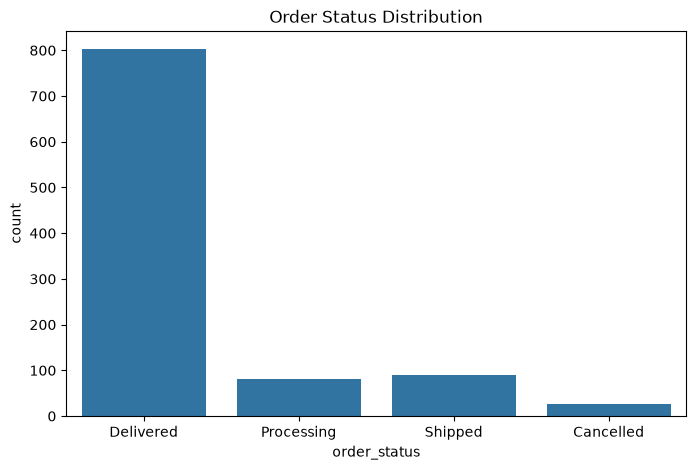

In [70]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders_df,
    x="order_status"
)

plt.title("Order Status Distribution")

plt.show()

## Payments Analysis

In [71]:
payments_df["payment_method"].value_counts()

payment_method
Net Banking         215
UPI                 207
Debit Card          198
Credit Card         194
Cash on Delivery    186
Name: count, dtype: int64

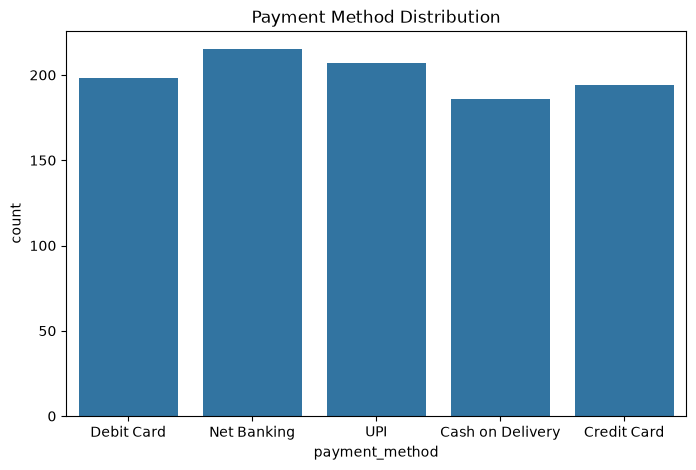

In [72]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=payments_df,
    x="payment_method"
)

plt.title("Payment Method Distribution")

plt.show()

In [73]:
payments_df["payment_status"].value_counts()

payment_status
Success    891
Pending     82
Failed      27
Name: count, dtype: int64

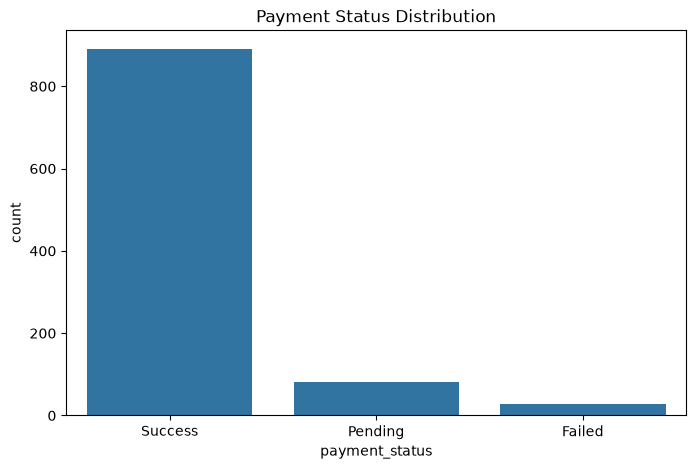

In [74]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=payments_df,
    x="payment_status"
)

plt.title("Payment Status Distribution")

plt.show()

## Business Insights

In [75]:
customers_df["city"].value_counts().head(10)

city
Jaipur       14
Mumbai       12
Delhi        12
Bhopal       11
Hyderabad    11
Indore       11
Chennai       9
Ahmedabad     7
Bangalore     7
Pune          6
Name: count, dtype: int64

In [76]:
customers_df["customer_segment"].value_counts()

customer_segment
Gold       31
Silver     28
Regular    21
Premium    20
Name: count, dtype: int64

In [77]:
customers_df.groupby(
    "customer_segment"
)["age"].mean().round(2)

customer_segment
Gold       43.81
Premium    38.35
Regular    39.24
Silver     37.89
Name: age, dtype: float64

In [78]:
products_df.groupby(
    "category_id"
)["price"].mean().round(2)

category_id
1     55834.0
2      2733.6
3       514.2
4     40751.2
5      2207.0
6      3884.6
7      1777.8
8      1212.0
9     23784.0
10     2592.0
Name: price, dtype: float64

## Correlation Analysis

In [79]:
correlation_columns = [
    "rating",
    "price",
    "stock_quantity",
    "discount_percentage",
    "cost_price"
]

products_df[correlation_columns].corr()

,rating,price,stock_quantity,discount_percentage,cost_price
rating,1.000000,-0.032918,0.217212,0.027309,-0.023941
price,-0.032918,1.000000,0.110414,-0.042466,0.992526
stock_quantity,0.217212,0.110414,1.000000,0.052491,0.136064
discount_percentage,0.027309,-0.042466,0.052491,1.000000,-0.029083
cost_price,-0.023941,0.992526,0.136064,-0.029083,1.000000


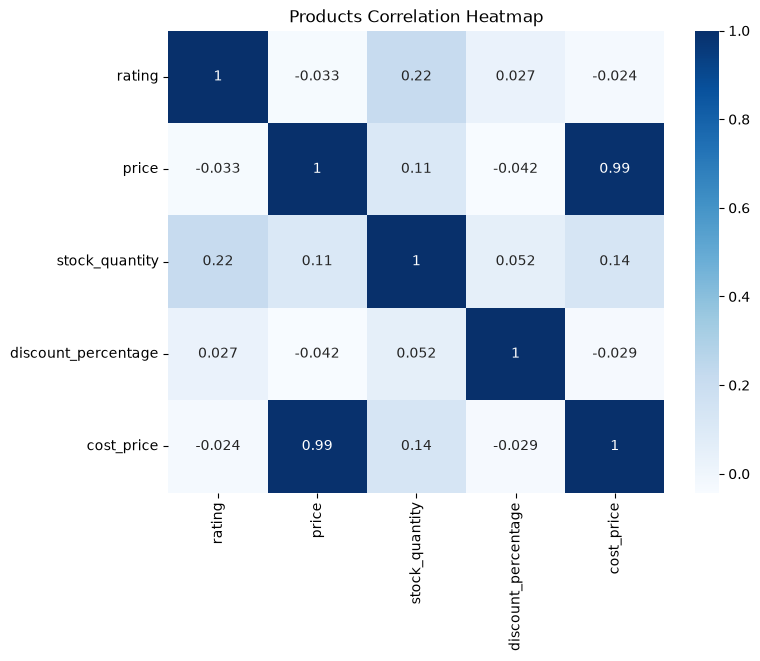

In [80]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    products_df[correlation_columns].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Products Correlation Heatmap")

plt.show()

## EDA Summary

### Key Findings

- No missing values were found in the datasets.
- No duplicate rows were present.
- Customer ages are well distributed.
- Customer segments are reasonably balanced.
- Payment success rate is high.
- Product prices vary across categories.
- The data is suitable for machine learning.